# CreditWise: An Intelligent Machine Learning-Based Loan Approval Prediction

### Three models will be used for classification task
1. Logistic
2. KNN (if too many features may perform comparitively poor)
3. Naive Bayes

## Importing libraries

In [368]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns                                               # For visualization
import matplotlib.pyplot as plt                                     # For visualization
from sklearn.impute import SimpleImputer                            # Imputing missing values
from sklearn.preprocessing import LabelEncoder, OneHotEncoder       # Encoding columns
from sklearn.model_selection import train_test_split                # Dividing dataset into train and test
from sklearn.linear_model import LogisticRegression                 # Logistic regression model
from sklearn.neighbors import KNeighborsClassifier                  # KNN classifier
from sklearn.preprocessing import StandardScaler                    # Scaling
from sklearn.naive_bayes import GaussianNB                          # Naive Bayes
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix    # Evaluatio metrics

# Data cleaning and Pre-Processing dataset

In [369]:
dataset = pd.read_csv("loan_approval_data.csv")
dataset.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [370]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [371]:
dataset.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [372]:
# 50 vising values in the dataset, corresponding to each feature

## Tackle missing values

In [373]:
dataset.shape

(1000, 20)

## Correctly indexing missing Applicant Id

In [374]:
dataset[dataset["Applicant_ID"].isnull()]

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
24,NaN,3899.0,8232.0,Unemployed,26.0,Single,3.0,778.0,NaN,0.38,18722.0,44324.0,33305.0,72.0,Home,Urban,Graduate,Female,Government,No
31,NaN,16502.0,2074.0,Salaried,31.0,Married,2.0,614.0,3.0,0.12,6610.0,24059.0,5861.0,48.0,Car,Urban,Graduate,Female,NaN,No
39,NaN,4612.0,2969.0,Salaried,32.0,Married,1.0,606.0,2.0,0.60,5901.0,17535.0,6624.0,36.0,Home,Semiurban,Not Graduate,Female,Business,No
77,NaN,17422.0,7617.0,Unemployed,48.0,Married,2.0,581.0,4.0,0.46,11936.0,7910.0,8145.0,84.0,Business,Rural,Not Graduate,Female,Business,No
81,NaN,15986.0,5136.0,Salaried,22.0,Married,0.0,554.0,1.0,0.21,4175.0,28810.0,24930.0,48.0,Car,Rural,Graduate,Male,Private,No
108,NaN,16820.0,8407.0,Contract,46.0,Single,1.0,NaN,3.0,0.21,8123.0,8328.0,4679.0,60.0,Home,Urban,Graduate,Male,NaN,No
121,NaN,15931.0,8680.0,Contract,43.0,Single,2.0,754.0,4.0,NaN,19203.0,32370.0,31175.0,12.0,Personal,Rural,Not Graduate,Male,Private,Yes
134,NaN,15545.0,4232.0,Salaried,55.0,Single,0.0,593.0,4.0,0.38,16105.0,34283.0,29242.0,84.0,Education,Urban,Graduate,Female,Unemployed,No
166,NaN,11339.0,8684.0,Salaried,44.0,Married,1.0,582.0,1.0,0.29,3816.0,17199.0,31431.0,36.0,Home,Urban,Graduate,Female,Government,No
191,NaN,11208.0,1165.0,Salaried,43.0,Single,2.0,781.0,1.0,0.50,13579.0,41797.0,19907.0,72.0,Education,Rural,Not Graduate,Female,MNC,NaN


In [375]:
dataset["Applicant_ID"]=range(1, len(dataset)+1)

In [376]:
# Check few columns which were missing earlier
print(f"Number of null values in Applicant_ID: {dataset['Applicant_ID'].isnull().sum()}")
print(dataset["Applicant_ID"].loc[915:995])

Number of null values in Applicant_ID: 0
915    916
916    917
917    918
918    919
919    920
      ... 
991    992
992    993
993    994
994    995
995    996
Name: Applicant_ID, Length: 81, dtype: int64


## Fill missing values for categorical and Numerical features

In [377]:
# To impute missing numerical values, we check skewness in dataset

In [378]:
dataset.skew(numeric_only=True)

Applicant_ID          0.000000
Applicant_Income      0.072506
Coapplicant_Income   -0.051148
Age                  -0.020688
Dependents            0.066393
Credit_Score         -0.058889
Existing_Loans        0.081129
DTI_Ratio             0.055658
Savings               0.010542
Collateral_Value      0.064271
Loan_Amount          -0.025619
Loan_Term            -0.001536
dtype: float64

In [379]:
# creating copy of original dataset
dataset_copy = dataset.copy(deep=True)

In [380]:
# Display numeric data tables
numeric_cols= dataset.select_dtypes(include=['number']).columns
print(numeric_cols)

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [381]:
# Filling numerical values 
# Impute all columns at once using their respective means
num_imp = SimpleImputer(strategy ="mean")
dataset[numeric_cols] = num_imp.fit_transform(dataset[numeric_cols])


In [382]:
# Display categorical data tables
categ_cols = dataset.select_dtypes(include=['object']).columns
print(f"\n {categ_cols}")
print(dataset.isnull().sum())



 Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


In [383]:
# dataset[categ_cols]= dataset[categ_cols] .fillna(dataset[categ_cols].mode().iloc[0])
categ_imp = SimpleImputer(strategy ="most_frequent")
dataset[categ_cols] = categ_imp.fit_transform(dataset[categ_cols])


In [384]:
dataset.isnull().sum()   # Data is pre-processed with no missing values

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### Dataset null values are handled using, indexing for applicant ID, imputing by mean for numerical values and mode for categorical values. Also missing target values are also imputed

# EDA

In [385]:
class_count = dataset["Loan_Approved"].value_counts()
print(class_count)

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


## Imbalanced Dataset : Target variable distribution

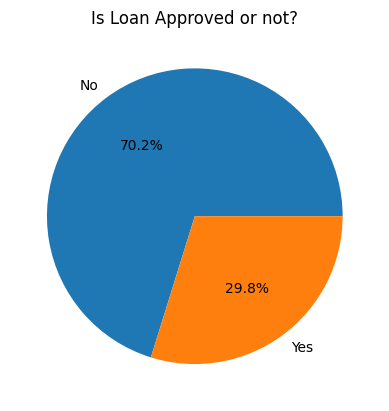

In [386]:
plt.pie(class_count,labels=["No","Yes"],autopct = "%1.1f%%")
plt.title("Is Loan Approved or not?")
plt.show()

In [387]:
# data types are correct in the dataset
dataset.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,288.819436,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,23.630794
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.750000,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,24.000000
50%,500.500000,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,48.000000
75%,750.250000,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## Analyse categories

### Categorical feature distributions

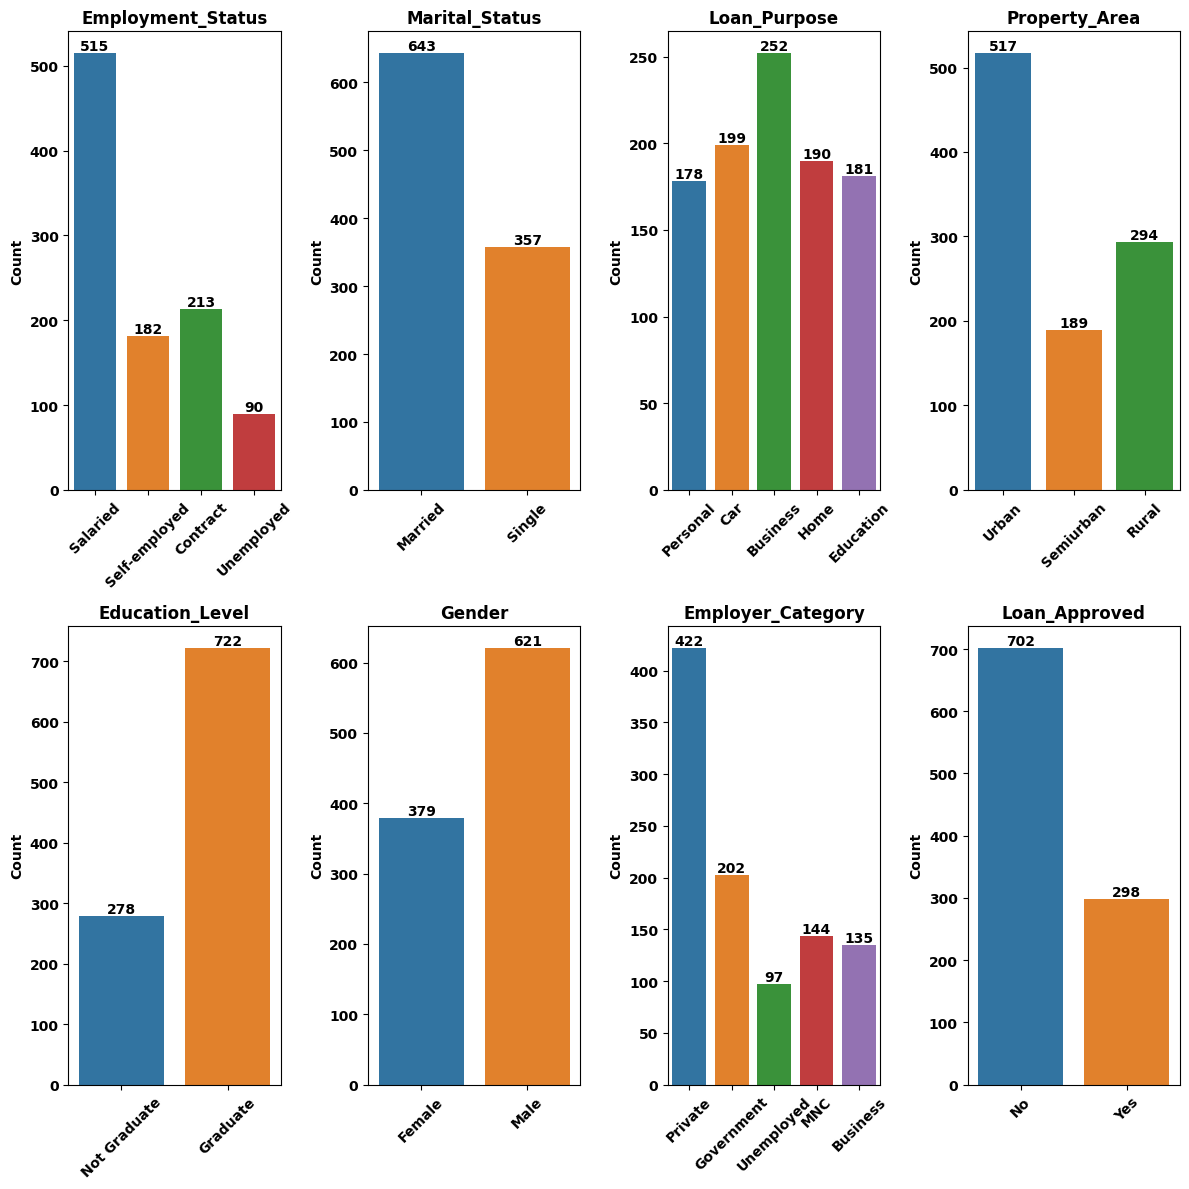

In [388]:
plt.figure(figsize=(12,12))
for i, col in enumerate(categ_cols, 1):
    plt.subplot(2, 4, i)
    ax = sns.countplot(x=col, data=dataset,hue=col)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col, fontweight='bold')
    ax.set_xlabel('')   # Remove x-axis label
    ax.set_ylabel('Count', fontweight='bold')
    for container in ax.containers:
        ax.bar_label(container, fontweight='bold')
    plt.xticks(rotation=45,fontweight='bold')
    plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

### Numerical feature distributions

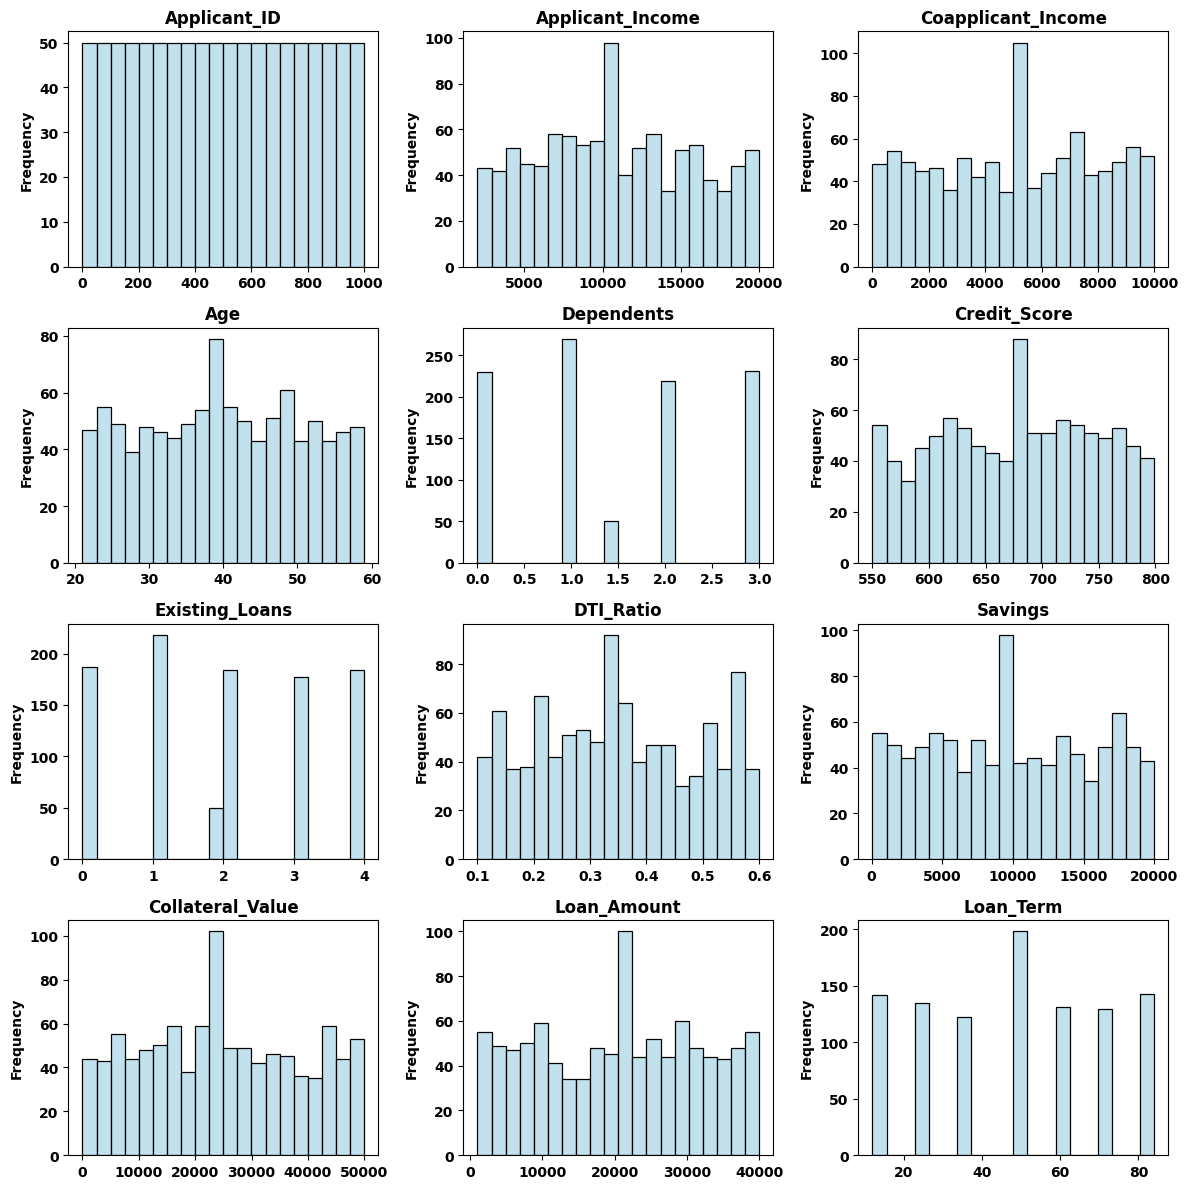

In [389]:
plt.figure(figsize=(12,12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    ax = sns.histplot(
    data=dataset,
    x= col,
    color="lightblue",
    bins=20
)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frequency', fontweight='bold')
    ax.set_xlabel('')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

### Numerical features vs target and outlier detection

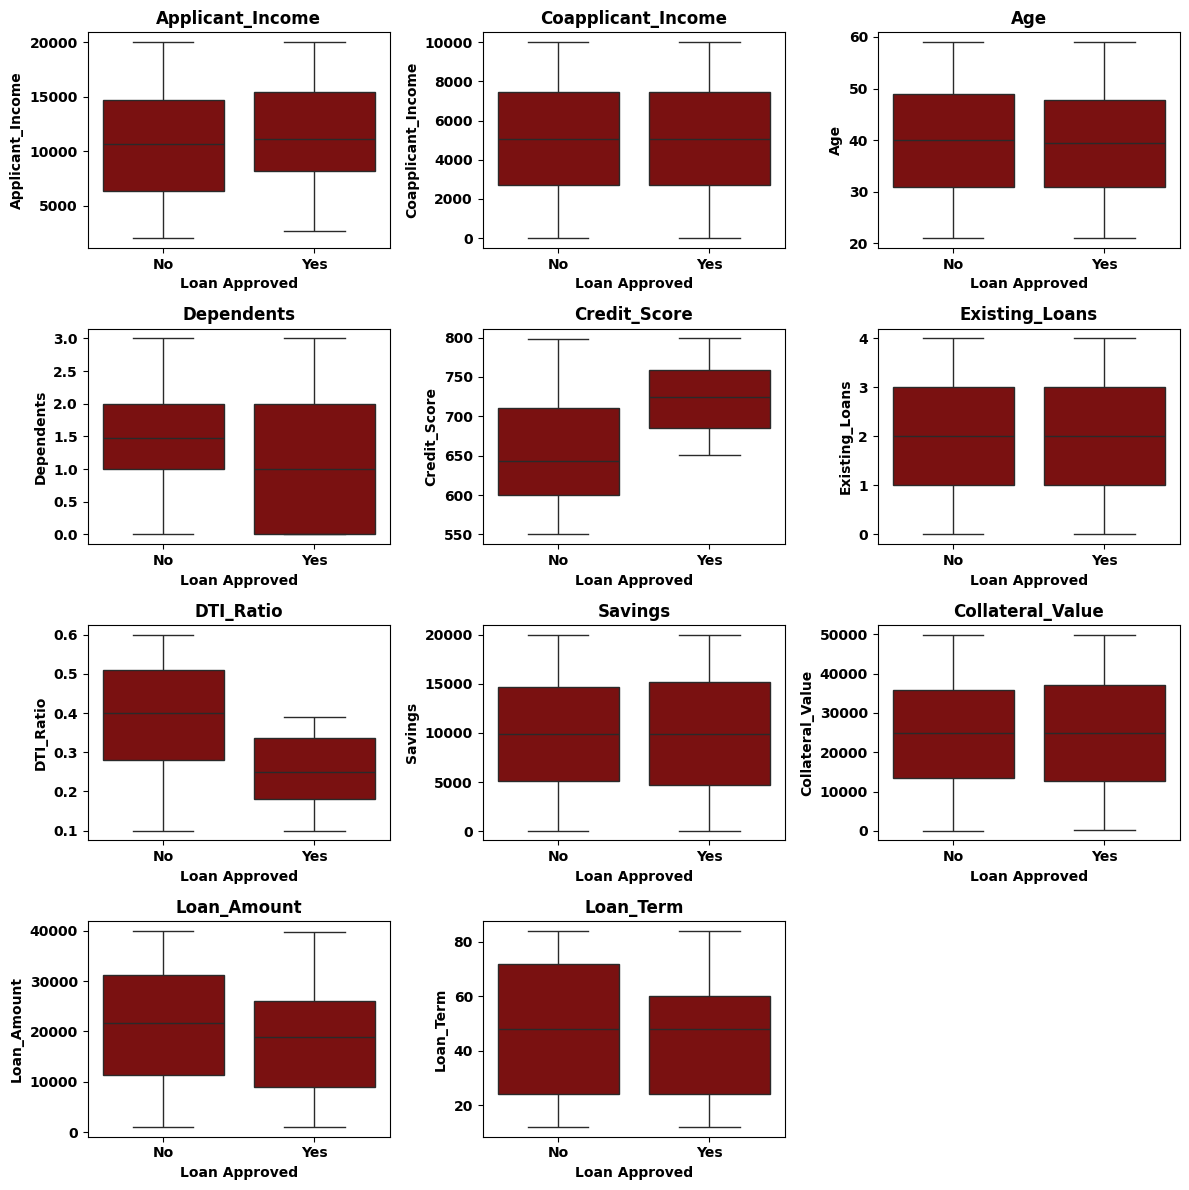

In [390]:
plt.figure(figsize=(12,12))
cols = [col for col in numeric_cols if col != "Applicant_ID"]
for i, col in enumerate(cols, 1):
    plt.subplot(4, 3, i)
    ax = sns.boxplot(
        data=dataset,
        x="Loan_Approved",
        y=col,
        color="Darkred"
        )

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Loan Approved', fontweight='bold')
    ax.set_ylabel(col, fontweight='bold')

    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')

plt.tight_layout()
plt.show()

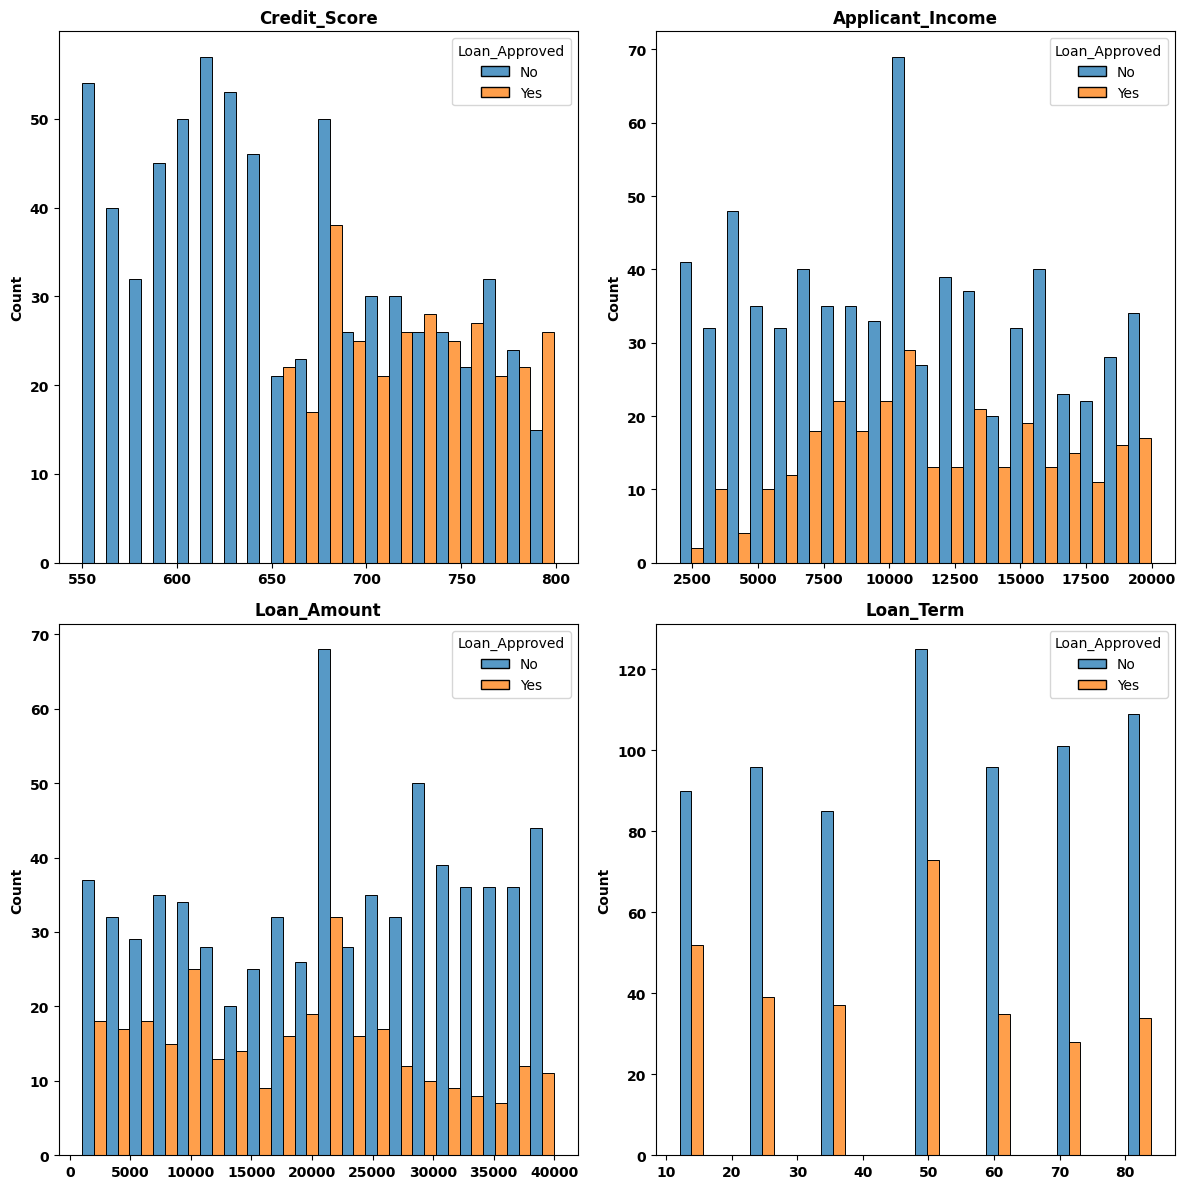

In [391]:
major_obser = ["Credit_Score", "Applicant_Income", "Loan_Amount", "Loan_Term"]
plt.figure(figsize=(12,12))
for i, col in enumerate(major_obser, 1):
    plt.subplot(2, 2, i)
    ax = sns.histplot(
    data=dataset,
    x=col,
    hue="Loan_Approved",
    bins = 20,
    multiple = "dodge"
    )
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_xlabel('')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()


# Cleaned Dataset

In [392]:
df_1 = dataset.copy(deep=True)

In [393]:
df_1.drop("Applicant_ID", axis =1, inplace=True)

## Encoding the Dataset

In [394]:
# Identifying the number of unique values in the categorical features
df_1[categ_cols].nunique()

Employment_Status    4
Marital_Status       2
Loan_Purpose         5
Property_Area        3
Education_Level      2
Gender               2
Employer_Category    5
Loan_Approved        2
dtype: int64

In [395]:
one_hot_cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
# One hot encoder creates separate binary (0/1) columns for each category, used for nominal categorical variables where no natural order exists, Prevents model from assuming any numerical relationship between categories.
label_encoder_cols = ["Education_Level","Loan_Approved"]
# Label Encoding converts each category into an integer value, Suitable when categories have a natural order (ordinal data), used in binary categories, but for purely nominal categories, assigned numbers do not imply any real ranking.

In [396]:
LE = LabelEncoder()
df_1["Education_Level"] = LE.fit_transform(df_1["Education_Level"])
df_1["Loan_Approved"] = LE.fit_transform(df_1["Loan_Approved"])


In [397]:
df_1.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [398]:
OHE = OneHotEncoder(drop = "first",sparse_output = False, handle_unknown = "ignore")
encoded= OHE.fit_transform(df_1[one_hot_cols])  # provides encoded values in 2D array form , which need to be converted to dataframe

In [399]:
encoded # 2D ARRAY

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 15))

In [400]:
# converting encoded values to dataframe
encoded_df1 = pd.DataFrame(encoded, columns = OHE.get_feature_names_out(one_hot_cols ) , index = df_1.index )

In [401]:
OHE.get_feature_names_out(one_hot_cols )

array(['Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male',
       'Employer_Category_Government', 'Employer_Category_MNC',
       'Employer_Category_Private', 'Employer_Category_Unemployed'],
      dtype=object)

In [402]:
cleaned_dataset = pd.concat([df_1.drop(columns=one_hot_cols),encoded_df1],axis=1)

In [403]:
cleaned_dataset.shape

(1000, 28)

In [404]:
cleaned_dataset.info()  # all values converted to numbers

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [405]:
cleaned_dataset.head()   # All columns now have numeric data

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [406]:
cleaned_dataset_orig = cleaned_dataset.copy()

# Visualizing Heat map of original dataset to analyze correlation among features

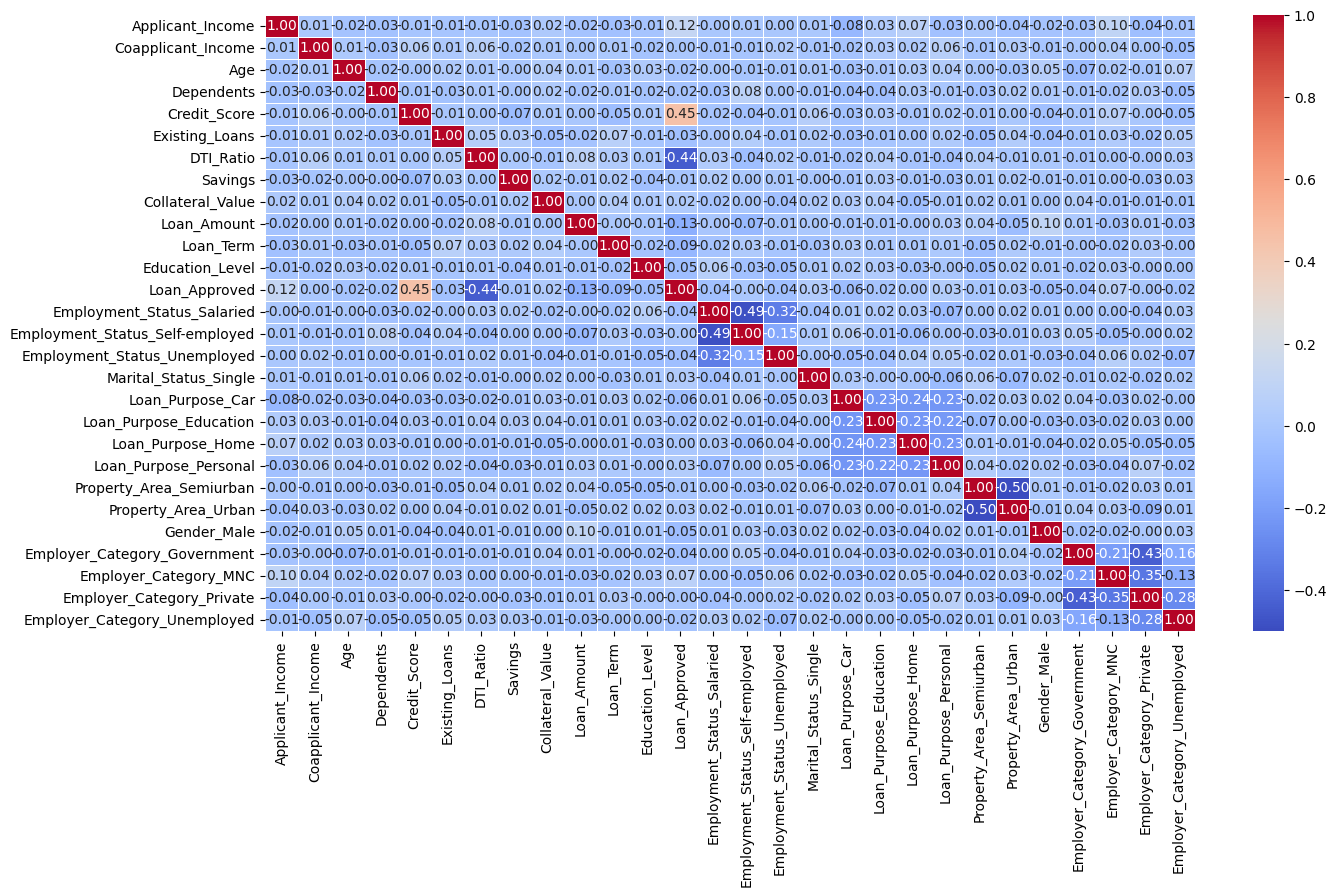

In [407]:
# Drawing heatmap for the original Dataset
num_cols = cleaned_dataset_orig.select_dtypes(include="number")
corr_matrix = num_cols.corr()  # By default uses pearson correlation (rank )

plt.figure(figsize=(15, 8))
sns.heatmap(cleaned_dataset_orig.corr(),annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [408]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)  # correlation values wrt loan_Approved

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# Split Dataset

In [409]:
X = cleaned_dataset_orig.drop("Loan_Approved",axis=1)
Y = cleaned_dataset_orig["Loan_Approved"]

In [410]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [411]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [412]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scaled Dataset

In [413]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [414]:
x_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

# Baseline Model A : Model training without featured engineered dataset

In [415]:
cleaned_dataset_orig.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level',
       'Loan_Approved', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car', 'Loan_Purpose_Education',
       'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Gender_Male', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'],
      dtype='object')

In [416]:
cleaned_dataset_orig.shape

(1000, 28)

# Logistic Regression

In [417]:
model_Log_R = LogisticRegression()
model_Log_R.fit(x_train_scaled,y_train)
y_pred = model_Log_R.predict(x_test_scaled)
print(f"classification report :\n{classification_report(y_test,y_pred)}")
print(f"accuracy: {accuracy_score(y_test,y_pred)}")
print(f"precision: {precision_score(y_test,y_pred)}")
print(f"recall: {recall_score(y_test,y_pred)}")
print(f"f1: {f1_score(y_test,y_pred)}")

classification report :
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       139
           1       0.78      0.77      0.78        61

    accuracy                           0.86       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.86      0.86      0.86       200

accuracy: 0.865
precision: 0.7833333333333333
recall: 0.7704918032786885
f1: 0.7768595041322314


# KNN

In [418]:
model_KNN = KNeighborsClassifier(n_neighbors=5)
model_KNN.fit(x_train_scaled,y_train)
y_pred_KNN = model_KNN.predict(x_test_scaled)
print(f"classification report :\n{classification_report(y_test,y_pred_KNN)}")
print(f"accuracy: {accuracy_score(y_test,y_pred_KNN)}")
print(f"precision: {precision_score(y_test,y_pred_KNN)}")
print(f"recall: {recall_score(y_test,y_pred_KNN)}")
print(f"f1: {f1_score(y_test,y_pred_KNN)}")

classification report :
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       139
           1       0.63      0.52      0.57        61

    accuracy                           0.76       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.75      0.76      0.75       200

accuracy: 0.76
precision: 0.6274509803921569
recall: 0.5245901639344263
f1: 0.5714285714285714


# Naive Bayes


In [419]:
model_NB = GaussianNB()
model_NB.fit(x_train_scaled,y_train)
y_pred_NB = model_NB.predict(x_test_scaled)
print(f"classification report :\n{classification_report(y_test,y_pred_NB)}")
print(f"accuracy: {accuracy_score(y_test,y_pred_NB)}")
print(f"precision: {precision_score(y_test,y_pred_NB)}")
print(f"recall: {recall_score(y_test,y_pred_NB)}")
print(f"f1: {f1_score(y_test,y_pred_NB)}")

classification report :
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       139
           1       0.80      0.74      0.77        61

    accuracy                           0.86       200
   macro avg       0.85      0.83      0.84       200
weighted avg       0.86      0.86      0.86       200

accuracy: 0.865
precision: 0.8035714285714286
recall: 0.7377049180327869
f1: 0.7692307692307693


# Best model on the basis of Precision ==> Naive Bayes with Precision 80.35%

# Model B : Model training with featured engineered dataset¶

# Feature Engineering

In [420]:
# Using cleaned_dataset
cleaned_dataset.shape

(1000, 28)

In [421]:
cleaned_dataset["DTI_Ratio_sq"] = cleaned_dataset["DTI_Ratio"] ** 2
cleaned_dataset["Credit_Score_sq"] = cleaned_dataset["Credit_Score"] ** 2
cleaned_dataset["Applicant_Income_log"] = np.log1p(cleaned_dataset["Applicant_Income"])

X = cleaned_dataset.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = cleaned_dataset["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [422]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975


## Logistic Regression 

In [423]:
model_Log_R = LogisticRegression()
model_Log_R.fit(X_train_scaled,y_train)
y_pred = model_Log_R.predict(X_test_scaled)
print(f"classification report :\n{classification_report(y_test,y_pred)}")
print(f"accuracy: {accuracy_score(y_test,y_pred)}")
print(f"precision: {precision_score(y_test,y_pred)}")
print(f"recall: {recall_score(y_test,y_pred)}")
print(f"f1: {f1_score(y_test,y_pred)}")

classification report :
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       139
           1       0.78      0.84      0.81        61

    accuracy                           0.88       200
   macro avg       0.86      0.87      0.86       200
weighted avg       0.88      0.88      0.88       200

accuracy: 0.88
precision: 0.7846153846153846
recall: 0.8360655737704918
f1: 0.8095238095238095


## KNN classifier

In [424]:
model_KNN = KNeighborsClassifier(n_neighbors=3)
model_KNN.fit(X_train_scaled,y_train)
y_pred_KNN = model_KNN.predict(X_test_scaled)
print(f"classification report :\n{classification_report(y_test,y_pred_KNN)}")
print(f"accuracy: {accuracy_score(y_test,y_pred_KNN)}")
print(f"precision: {precision_score(y_test,y_pred_KNN)}")
print(f"recall: {recall_score(y_test,y_pred_KNN)}")
print(f"f1: {f1_score(y_test,y_pred_KNN)}")


classification report :
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       139
           1       0.59      0.59      0.59        61

    accuracy                           0.75       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.75      0.75      0.75       200

accuracy: 0.75
precision: 0.5901639344262295
recall: 0.5901639344262295
f1: 0.5901639344262295


## Naive Bayes

In [425]:
model_NB = GaussianNB()
model_NB.fit(X_train_scaled,y_train)
y_pred_NB = model_NB.predict(X_test_scaled)
print(f"classification report :\n{classification_report(y_test,y_pred_NB)}")
print(f"accuracy: {accuracy_score(y_test,y_pred_NB)}")
print(f"precision: {precision_score(y_test,y_pred_NB)}")
print(f"recall: {recall_score(y_test,y_pred_NB)}")
print(f"f1: {f1_score(y_test,y_pred_NB)}")

classification report :
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       139
           1       0.81      0.70      0.75        61

    accuracy                           0.86       200
   macro avg       0.84      0.82      0.83       200
weighted avg       0.86      0.86      0.86       200

accuracy: 0.86
precision: 0.8113207547169812
recall: 0.7049180327868853
f1: 0.7543859649122807


# Improved Evaluation Metrics for feature engineered dataset

# For feature engineered dataset:
1. Recall improved by 7% for Logistic Regression model and prescision retained its value at 78%
2. Precision improved by 1% for Naive Bayes and recall decresed by 4%